In [1]:
import os, io, zipfile, requests, shutil

if os.path.exists("texturepacks"):
    shutil.rmtree("texturepacks")
os.makedirs("texturepacks", exist_ok=True)

urls = """
https://modrinth.com/resourcepack/allure-pack
https://modrinth.com/resourcepack/ashen
https://modrinth.com/resourcepack/bare-bones
https://modrinth.com/resourcepack/blockpixel
https://modrinth.com/resourcepack/candy-texture-pack
https://modrinth.com/resourcepack/cartoon-texture-pack
https://modrinth.com/resourcepack/chinese-mythology-mash-up
https://modrinth.com/resourcepack/city-texture-pack
https://modrinth.com/resourcepack/faithful-32x
https://modrinth.com/resourcepack/fallout-mashup
https://modrinth.com/resourcepack/fantasy-texture-pack
https://modrinth.com/resourcepack/festive-mash-up
https://modrinth.com/resourcepack/greek-mythology-mash-up
https://modrinth.com/resourcepack/halloween-mash-up
https://modrinth.com/resourcepack/kdcraft
https://modrinth.com/resourcepack/mass-effect-mash-up
https://modrinth.com/resourcepack/minecraft-lite-edition-wool-edition
https://modrinth.com/resourcepack/natural-texture-pack
https://modrinth.com/resourcepack/norse-mythology-mash-up
https://modrinth.com/resourcepack/pastelcraft
https://modrinth.com/resourcepack/pattern-texture-pack
https://modrinth.com/resourcepack/pirates-of-the-caribbean-mash-up
https://modrinth.com/resourcepack/pixel-perfection-legacy
https://modrinth.com/resourcepack/plastic-texture-pack
https://modrinth.com/resourcepack/pollachius
https://modrinth.com/resourcepack/steampunk-texture-pack
https://modrinth.com/resourcepack/super-cute
https://modrinth.com/resourcepack/super-mario-mash-up
https://modrinth.com/resourcepack/wind-waker-edition
""".strip().splitlines()

def is_block_dir(path):
    name = os.path.basename(path).lower()
    parent = os.path.basename(os.path.dirname(path)).lower()
    return parent == "textures" and name in {"block", "blocks"}

for url in urls:
    slug = url.rstrip("/").split("/")[-1]
    print(f"Fetching {slug}")
    r = requests.get(f"https://api.modrinth.com/v2/project/{slug}/version")
    r.raise_for_status()
    versions = r.json()
    if not versions:
        print("No versions found")
        continue

    file_url = versions[0]["files"][0]["url"]
    resp = requests.get(file_url)
    resp.raise_for_status()

    base = f"texturepacks/{slug}"
    os.makedirs(base, exist_ok=True)

    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        z.extractall(base)

    images_dir = os.path.join(base, "images")
    copied = 0
    for root, dirs, files in os.walk(base):
        if is_block_dir(root):
            os.makedirs(images_dir, exist_ok=True)
            for fn in files:
                if fn.lower().endswith(".png"):
                    src = os.path.join(root, fn)
                    dst = os.path.join(images_dir, fn)
                    if os.path.exists(dst):
                        stem, ext = os.path.splitext(fn)
                        i = 1
                        while os.path.exists(dst):
                            dst = os.path.join(images_dir, f"{stem}_{i}{ext}")
                            i += 1
                    shutil.copy2(src, dst)
                    copied += 1

    if copied:
        for item in os.listdir(base):
            path = os.path.join(base, item)
            if path != images_dir:
                shutil.rmtree(path, ignore_errors=True)
        print(f"Kept {images_dir}")
    else:
        print("No block textures copied")

print("All packs processed.")


Fetching allure-pack
Kept texturepacks/allure-pack/images
Fetching ashen
Kept texturepacks/ashen/images
Fetching bare-bones
Kept texturepacks/bare-bones/images
Fetching blockpixel
Kept texturepacks/blockpixel/images
Fetching candy-texture-pack
Kept texturepacks/candy-texture-pack/images
Fetching cartoon-texture-pack
Kept texturepacks/cartoon-texture-pack/images
Fetching chinese-mythology-mash-up
Kept texturepacks/chinese-mythology-mash-up/images
Fetching city-texture-pack
Kept texturepacks/city-texture-pack/images
Fetching faithful-32x
Kept texturepacks/faithful-32x/images
Fetching fallout-mashup
Kept texturepacks/fallout-mashup/images
Fetching fantasy-texture-pack
Kept texturepacks/fantasy-texture-pack/images
Fetching festive-mash-up
Kept texturepacks/festive-mash-up/images
Fetching greek-mythology-mash-up
Kept texturepacks/greek-mythology-mash-up/images
Fetching halloween-mash-up
Kept texturepacks/halloween-mash-up/images
Fetching kdcraft
Kept texturepacks/kdcraft/images
Fetching mas

In [2]:
from google.colab import drive

drive.mount('/content/drive')

os.makedirs('/root/.kaggle', exist_ok=True)

# Copy kaggle.json from your Drive home folder
!cp /content/drive/MyDrive/kaggle.json /root/.kaggle/

!chmod 600 /root/.kaggle/kaggle.json

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from kaggle.api.kaggle_api_extended import KaggleApi

DATASET = "urvishahir/minecraft-block-textures-dataset"
BASE = "default"
IMAGES = os.path.join(BASE, "images")

if os.path.exists(BASE):
    shutil.rmtree(BASE, ignore_errors=True)
os.makedirs(BASE, exist_ok=True)

api = KaggleApi()
api.authenticate()

os.makedirs(BASE, exist_ok=True)
api.dataset_download_files(DATASET, path=BASE, unzip=True)

# Move all .png files into default/images
os.makedirs(IMAGES, exist_ok=True)
for root, _, files in os.walk(BASE):
    if os.path.abspath(root) == os.path.abspath(IMAGES):
        continue
    for fn in files:
        if fn.lower().endswith(".png"):
            src = os.path.join(root, fn)
            dst = os.path.join(IMAGES, fn)
            if os.path.abspath(src) == os.path.abspath(dst):
                continue
            if os.path.exists(dst):
                stem, ext = os.path.splitext(fn)
                i = 1
                while os.path.exists(dst):
                    dst = os.path.join(IMAGES, f"{stem}_{i}{ext}")
                    i += 1
            shutil.move(src, dst)

# Remove everything in default except the images folder
for item in os.listdir(BASE):
    path = os.path.join(BASE, item)
    if os.path.abspath(path) != os.path.abspath(IMAGES):
        if os.path.isdir(path):
            shutil.rmtree(path, ignore_errors=True)
        else:
            os.remove(path)

print(f"Kept {IMAGES}")

Dataset URL: https://www.kaggle.com/datasets/urvishahir/minecraft-block-textures-dataset
Kept default/images


In [4]:
from torch.utils.data import Dataset
from PIL import Image

class MinecraftTextureDataset(Dataset):
    def __init__(self, image_dir, pack_id="default", rgb_background=(128, 128, 128)):
        """
        Args:
            image_dir (str): Directory containing texture PNGs.
            pack_id (str): Name of the texture pack (e.g. 'ashen', 'default', etc.).
            rgb_background (tuple): RGB color to use as background for RGBA textures.
        """
        self.image_dir = image_dir
        self.pack_id = pack_id
        self.rgb_background = rgb_background

        # collect all PNGs
        self.image_files = sorted(
            [f for f in os.listdir(image_dir) if f.lower().endswith(".png")]
        )

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        path = os.path.join(self.image_dir, img_name)

        # open image and convert RGBA → RGB using the background
        img = Image.open(path).convert("RGBA")
        bg = Image.new("RGB", img.size, self.rgb_background)
        bg.paste(img, mask=img.split()[3])  # use alpha channel as mask
        image_rgb = bg

        texture_name = os.path.splitext(img_name)[0]

        return {
            "image_rgb": image_rgb,
            "texture_name": texture_name,
            "pack_id": self.pack_id,
        }

In [5]:
# Default dataset
default_dataset = MinecraftTextureDataset("default/images", pack_id="default")

# --- Remove unwanted textures ---
bad_textures = {
    "destroy_stage_0","destroy_stage_1","destroy_stage_2","destroy_stage_3",
    "destroy_stage_4","destroy_stage_5","destroy_stage_6","destroy_stage_7",
    "destroy_stage_8","destroy_stage_9",
    "grass_block_side_overlay",
    "redstone_dust_overlay",
    "water_overlay",
    "bamboo_fence_gate_particle",
    "bamboo_fence_particle",
    "dried_ghast_hydration_0_bottom","dried_ghast_hydration_0_east",
    "dried_ghast_hydration_0_north","dried_ghast_hydration_0_south",
    "dried_ghast_hydration_0_tentacles","dried_ghast_hydration_0_top",
    "dried_ghast_hydration_0_west",
    "dried_ghast_hydration_1_bottom","dried_ghast_hydration_1_east",
    "dried_ghast_hydration_1_north","dried_ghast_hydration_1_south",
    "dried_ghast_hydration_1_tentacles","dried_ghast_hydration_1_top",
    "dried_ghast_hydration_1_west",
    "dried_ghast_hydration_2_bottom","dried_ghast_hydration_2_east",
    "dried_ghast_hydration_2_north","dried_ghast_hydration_2_south",
    "dried_ghast_hydration_2_tentacles","dried_ghast_hydration_2_top",
    "dried_ghast_hydration_2_west",
    "dried_ghast_hydration_3_bottom","dried_ghast_hydration_3_east",
    "dried_ghast_hydration_3_north","dried_ghast_hydration_3_south",
    "dried_ghast_hydration_3_tentacles","dried_ghast_hydration_3_top",
    "dried_ghast_hydration_3_west",
}

default_dataset.image_files = [
    f for f in default_dataset.image_files
    if (
        os.path.splitext(f)[0] not in bad_textures
        and "debug" not in os.path.splitext(f)[0].lower()
    )
]

# --- Drop non-square textures in default dataset ---
filtered_files = []
default_square_map = {}

for fname in default_dataset.image_files:
    path = os.path.join(default_dataset.image_dir, fname)
    tex_name = os.path.splitext(fname)[0]
    with Image.open(path) as im:
        w, h = im.size
    if w == h:
        filtered_files.append(fname)
        default_square_map[tex_name] = w  # store tile size

default_dataset.image_files = filtered_files

# Function to crop repeated tall/wide tiles
def crop_repeated_tile(img, tile_size):
    w, h = img.size
    if w == tile_size and h > tile_size and (h % tile_size == 0):
        return img.crop((0, 0, tile_size, tile_size))
    if h == tile_size and w > tile_size and (w % tile_size == 0):
        return img.crop((0, 0, tile_size, tile_size))
    return img

# Texture pack datasets
texturepacks_root = "texturepacks"
pack_datasets = {}

for pack_id in sorted(os.listdir(texturepacks_root)):
    pack_path = os.path.join(texturepacks_root, pack_id, "images")
    if not os.path.isdir(pack_path):
        continue

    dataset = MinecraftTextureDataset(pack_path, pack_id=pack_id)

    corrected = []
    for fname in dataset.image_files:
        tex_name = os.path.splitext(fname)[0]
        path = os.path.join(pack_path, fname)

        if tex_name in default_square_map:
            tile_size = default_square_map[tex_name]
            with Image.open(path) as im:
                w, h = im.size

            if w != h:  # only crop non-square pack textures
                try:
                    with Image.open(path) as im:
                        new_img = crop_repeated_tile(im, tile_size)
                        if new_img.size != im.size:
                            print(f"[CROPPED] {pack_id}/{tex_name}: {im.size} -> {new_img.size}")
                        new_img.save(path)
                except Exception as e:
                    print(f"[WARN] Failed to crop {pack_id}/{fname}: {e}")

        corrected.append(fname)

    dataset.image_files = corrected
    pack_datasets[pack_id] = dataset

print(f"Loaded {len(default_dataset)} default textures after filtering")
print(f"Loaded {len(pack_datasets)} texture pack datasets: {list(pack_datasets.keys())}")

[CROPPED] allure-pack/beacon: (16, 64) -> (16, 16)
[CROPPED] allure-pack/firefly_bush: (16, 64) -> (16, 16)
[CROPPED] allure-pack/furnace_front_on: (16, 48) -> (16, 16)
[CROPPED] ashen/chiseled_nether_bricks: (16, 128) -> (16, 16)
[CROPPED] ashen/cyan_glazed_terracotta: (16, 96) -> (16, 16)
[CROPPED] ashen/furnace_front_on: (16, 112) -> (16, 16)
[CROPPED] ashen/glowstone: (16, 128) -> (16, 16)
[CROPPED] ashen/jack_o_lantern: (16, 64) -> (16, 16)
[CROPPED] ashen/soul_torch: (16, 80) -> (16, 16)
[CROPPED] ashen/torch: (16, 80) -> (16, 16)
[CROPPED] blockpixel/furnace_front_on: (16, 80) -> (16, 16)
[CROPPED] blockpixel/redstone_ore: (16, 96) -> (16, 16)
[CROPPED] candy-texture-pack/dead_bush: (16, 128) -> (16, 16)
[CROPPED] candy-texture-pack/diamond_block: (16, 256) -> (16, 16)
[CROPPED] candy-texture-pack/emerald_block: (16, 256) -> (16, 16)
[CROPPED] candy-texture-pack/obsidian: (16, 256) -> (16, 16)
[CROPPED] chinese-mythology-mash-up/furnace_front_on: (16, 64) -> (16, 16)
[CROPPED] c

In [6]:
def list_texture_names(dir_path):
    if not os.path.isdir(dir_path):
        return []
    names = []
    for fn in os.listdir(dir_path):
        if fn.startswith("."):
            continue  # skip hidden dotfiles
        if not fn.lower().endswith(".png"):
            continue
        names.append(os.path.splitext(fn)[0].strip().lower())
    return names

# ---- build default_names from the dataset  ----
default_names = set(
    os.path.splitext(f)[0].strip().lower()
    for f in getattr(default_dataset, "image_files", [])
)
print(f"Default textures (from filtered dataset): {len(default_names)}\n")

# track which default textures appear in any pack
used_in_packs = set()

total_without_default = 0

# clean up each pack directory: remove anything not in default_names
for pack_id, ds in pack_datasets.items():
    pack_dir = getattr(ds, "image_dir", os.path.join("texturepacks", pack_id, "images"))
    pack_names = list_texture_names(pack_dir)
    removed = 0

    for fn in os.listdir(pack_dir):
        path = os.path.join(pack_dir, fn)
        name = os.path.splitext(fn)[0].strip().lower()
        # delete non-pngs, hidden files, or textures not in filtered default set
        if (
            fn.startswith(".")
            or not fn.lower().endswith(".png")
            or name not in default_names
        ):
            try:
                os.remove(path)
                removed += 1
            except FileNotFoundError:
                pass

    # rebuild dataset's image list to reflect deletions
    ds.image_files = sorted(
        [f for f in os.listdir(pack_dir) if f.lower().endswith(".png")]
    )

    # record which default textures actually appear in this pack
    kept_names = {
        os.path.splitext(f)[0].strip().lower()
        for f in ds.image_files
    }
    used_in_packs.update(kept_names)

    print(f"{pack_id}: {len(pack_names)} textures; removed {removed}; kept {len(ds.image_files)}")
    total_without_default += len(ds.image_files)

# ---- prune default_dataset textures that appear in zero packs ----
orphan_names = default_names - used_in_packs  # present only in default
print(f"\nTextures present only in default (in 0 other packs): {len(orphan_names)}")

old_default_files = list(getattr(default_dataset, "image_files", []))
old_default_count = len(old_default_files)

filtered_default_files = []
removed_from_default = 0

for fn in old_default_files:
    name = os.path.splitext(fn)[0].strip().lower()
    if name in orphan_names:
        removed_from_default += 1
        continue
    filtered_default_files.append(fn)

default_dataset.image_files = filtered_default_files

print(
    f"Removed {removed_from_default} textures from default_dataset; "
    f"kept {len(default_dataset.image_files)}"
)

# recompute total_with_default using the pruned default_dataset
total_with_default = len(default_dataset.image_files)

print(f"\nTotal textures (default included, after pruning): {total_with_default + total_without_default}")
print(f"Total textures (texture packs only): {total_without_default}")

Default textures (from filtered dataset): 988

allure-pack: 1288 textures; removed 300; kept 988
ashen: 2073 textures; removed 1098; kept 975
bare-bones: 1113 textures; removed 132; kept 981
blockpixel: 1220 textures; removed 243; kept 977
candy-texture-pack: 1001 textures; removed 63; kept 938
cartoon-texture-pack: 844 textures; removed 61; kept 783
chinese-mythology-mash-up: 846 textures; removed 61; kept 785
city-texture-pack: 1073 textures; removed 95; kept 978
faithful-32x: 1080 textures; removed 93; kept 987
fallout-mashup: 1025 textures; removed 95; kept 930
fantasy-texture-pack: 1004 textures; removed 64; kept 940
festive-mash-up: 846 textures; removed 61; kept 785
greek-mythology-mash-up: 1073 textures; removed 95; kept 978
halloween-mash-up: 1004 textures; removed 64; kept 940
kdcraft: 1289 textures; removed 398; kept 891
mass-effect-mash-up: 846 textures; removed 61; kept 785
minecraft-lite-edition-wool-edition: 961 textures; removed 66; kept 895
natural-texture-pack: 1073 t

In [7]:
!pip install open-clip-torch

In [8]:
import torch
import open_clip

# --- Use the same CLIP encoder as IP-Adapter (paper + code) ---
model_name = "ViT-H-14"
pretrained = "laion2b_s32b_b79k"   # Official OpenCLIP LAION-2B weights

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load model + preprocess transforms
model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained
)

model = model.to(device)
model.eval()

print(f"Loaded {model_name} with weights '{pretrained}' on device: {device}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loaded ViT-H-14 with weights 'laion2b_s32b_b79k' on device: cuda


In [9]:
import random
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
import json

# define dataset splits
test_packs = {'plastic-texture-pack', 'steampunk-texture-pack'}
dev_packs = {'blockpixel', 'candy-texture-pack'}
all_packs = set(pack_datasets.keys())
train_packs = all_packs - test_packs - dev_packs

print(f"Train: {len(train_packs)}, Dev: {len(dev_packs)}, Test: {len(test_packs)}")

# path to cache file - (Renamed to reflect structure change)
DELTA_CACHE_PATH = "clip_deltas_and_targets_cache.json"

# cache clip embeddings to speed up training
embeddings_cache = {}

def precompute_deltas(pack_dict, default_dataset, clip_model, clip_preprocess, device):
    # computes Delta(x) AND caches the raw Target(x) vector for optimization
    clip_model.eval()

    # 1. compute normalized default embeddings first
    print("Encoding Default textures...")
    default_cache = {}

    # helper to process a dataset
    def get_normalized_features(dataset):
        cache = {}
        def collate_fn(batch):
            names = [b['texture_name'] for b in batch]
            imgs = torch.stack([clip_preprocess(b['image_rgb']) for b in batch])
            return names, imgs

        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False,
            num_workers=2,
            collate_fn=collate_fn
        )

        with torch.no_grad():
            for names, images in tqdm(loader, leave=False):
                images = images.to(device)
                features = clip_model.encode_image(images)
                # normalize immediately
                features = features / features.norm(dim=-1, keepdim=True)

                for name, feat in zip(names, features):
                    cache[name] = feat.cpu()
        return cache

    default_cache = get_normalized_features(default_dataset)

    # 2. compute pack deltas (Norm(Pack) - Norm(Default))
    final_cache = {}

    for pack_id, dataset in pack_dict.items():
        print(f"Calculating Deltas for: {pack_id}")
        pack_norm_vectors = get_normalized_features(dataset)

        # Store dictionary of {name: {'delta': ..., 'target_vec': ...}}
        pack_data = {}

        for name, pack_vec in pack_norm_vectors.items():
            # only calculate delta if we have the corresponding default texture
            if name in default_cache:
                default_vec = default_cache[name]

                # Delta = Norm(Pack) - Norm(Default)
                delta = pack_vec - default_vec

                # OPTIMIZATION: Cache both the Delta (for Input) and the Raw Vector (for Loss)
                pack_data[name] = {
                    "delta": delta,
                    "target_vec": pack_vec
                }

        final_cache[pack_id] = pack_data

    return final_cache

def save_delta_cache_to_json(cache, path):
    """
    Convert tensor cache -> plain Python lists and save as JSON.
    Structure: { pack_id: { texture_name: {'delta': [floats], 'target_vec': [floats]} } }
    """
    serializable = {}
    for pack_id, tex_dict in cache.items():
        serializable[pack_id] = {
            name: {
                "delta": data["delta"].tolist(),
                "target_vec": data["target_vec"].tolist()
            }
            for name, data in tex_dict.items()
        }
    with open(path, "w") as f:
        json.dump(serializable, f)


def load_delta_cache_from_json(path):
    """
    Load JSON cache and convert lists back to torch tensors.
    """
    with open(path, "r") as f:
        raw = json.load(f)

    cache = {}
    for pack_id, tex_dict in raw.items():
        cache[pack_id] = {
            name: {
                "delta": torch.tensor(data["delta"]),
                "target_vec": torch.tensor(data["target_vec"])
            }
            for name, data in tex_dict.items()
        }
    return cache


# ------------------ main: load-or-compute ------------------
if os.path.exists(DELTA_CACHE_PATH):
    print(f"\nLoading CLIP Delta cache from {DELTA_CACHE_PATH}...")
    embeddings_cache = load_delta_cache_from_json(DELTA_CACHE_PATH)
    print("Loaded cached deltas.")
else:
    print("\nStarting CLIP Delta pre-computation...")
    embeddings_cache = precompute_deltas(
        pack_datasets,
        default_dataset,
        model,
        preprocess,
        device
    )
    print("Delta pre-computation complete. Saving to JSON...")
    save_delta_cache_to_json(embeddings_cache, DELTA_CACHE_PATH)
    print(f"Saved CLIP Delta cache to {DELTA_CACHE_PATH}.")


class TripletMinecraftDataset(Dataset):
    def __init__(
        self,
        pack_datasets,
        default_dataset,
        embeddings_cache,
        split_packs,
        resolution=1024,
        num_style_samples=10
    ):
        self.pack_datasets = pack_datasets
        self.default_dataset = default_dataset
        self.embeddings_cache = embeddings_cache
        self.split_packs = list(split_packs)
        self.resolution = resolution
        self.num_style_samples = num_style_samples

        # map default texture names to indices for fast lookup
        self.default_map = {
            item['texture_name']: idx
            for idx, item in enumerate(default_dataset)
        }

        # build list of valid samples (pack_id, texture_name, pack_idx)
        self.samples = []
        for pack_id in self.split_packs:
            ds = pack_datasets[pack_id]
            for i in range(len(ds)):
                fname = ds.image_files[i]
                tname = os.path.splitext(fname)[0]
                # only keep if we calculated a delta for it (meaning it exists in default)
                if tname in self.embeddings_cache[pack_id]:
                    self.samples.append((pack_id, tname, i))

        # nearest neighbor upscale transform
        self.transform = transforms.Compose([
            transforms.Resize(
                (resolution, resolution),
                interpolation=InterpolationMode.NEAREST
            ),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pack_id, texture_name, pack_idx = self.samples[idx]

        # 1. get target image
        target_item = self.pack_datasets[pack_id][pack_idx]
        target_tensor = self.transform(target_item['image_rgb'])

        # 2. get default image (structure)
        default_idx = self.default_map[texture_name]
        default_item = self.default_dataset[default_idx]
        default_tensor = self.transform(default_item['image_rgb'])

        # 3. get style embedding (average of k random others)
        all_textures = list(self.embeddings_cache[pack_id].keys())
        # exclude the target itself to prevent cheating
        candidates = [t for t in all_textures if t != texture_name]

        k = self.num_style_samples
        if len(candidates) <= k:
            selected = candidates
        else:
            selected = random.sample(candidates, k)

        # Retrieve DELTAS for context (Note the ["delta"] access)
        vectors = [self.embeddings_cache[pack_id][n]["delta"] for n in selected]

        if not vectors:
            # degenerate case: no other textures
            vectors = [self.embeddings_cache[pack_id][texture_name]["delta"]]
            selected = [texture_name]

        # average the deltas
        style_embed = torch.stack(vectors).mean(dim=0)
        # normalize the result (with tiny epsilon safety)
        norm = style_embed.norm(dim=-1, keepdim=True).clamp_min(1e-8)
        style_embed = style_embed / norm

        # 4. OPTIMIZATION: Retrieve Pre-Computed TARGET VECTOR for Loss
        target_clip_vec = self.embeddings_cache[pack_id][texture_name]["target_vec"]

        return {
            "default_image": default_tensor,
            "target_image": target_tensor,
            "style_embedding": style_embed,
            "target_clip_embedding": target_clip_vec, # <--- New Key for optimized Loss
            "pack_id": pack_id,
            "texture_name": texture_name,
            "context_names": selected,
        }

# instantiate datasets
train_dataset = TripletMinecraftDataset(
    pack_datasets,
    default_dataset,
    embeddings_cache,
    train_packs,
)
dev_dataset = TripletMinecraftDataset(
    pack_datasets,
    default_dataset,
    embeddings_cache,
    dev_packs,
)

test_dataset = TripletMinecraftDataset(
    pack_datasets,
    default_dataset,
    embeddings_cache,
    test_packs,
)

print(f"Train Dataset: {len(train_dataset)} triplets")
print(f"Dev Dataset:   {len(dev_dataset)} triplets")
print(f"Test Dataset:  {len(test_dataset)} triplets")

Train: 25, Dev: 2, Test: 2

Loading CLIP Delta cache from clip_deltas_and_targets_cache.json...
Loaded cached deltas.
Train Dataset: 22263 triplets
Dev Dataset:   1915 triplets
Test Dataset:  1764 triplets


/tmp/ipython-input-1985642728.py:73: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


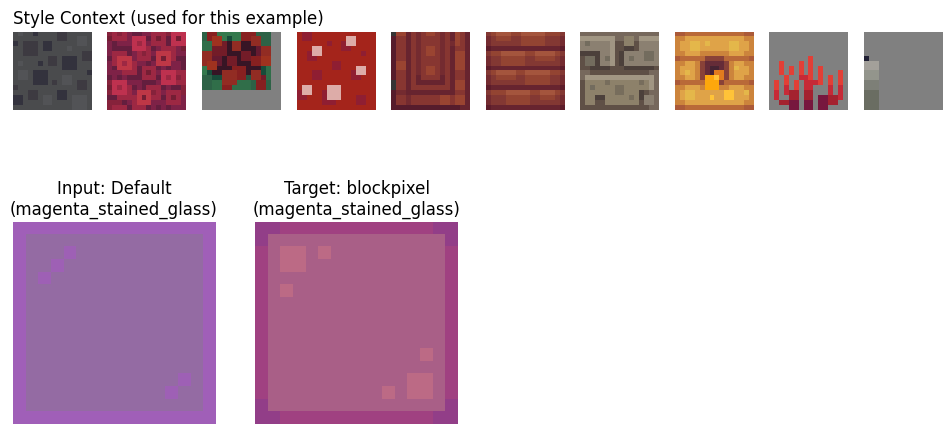

Pack ID: blockpixel
Texture Name: magenta_stained_glass
Context Textures used for Style Vector (10):
  - clay
  - fire_coral_block
  - sniffer_egg_very_cracked_bottom
  - red_mushroom_block
  - mangrove_door_bottom
  - mangrove_planks
  - cracked_stone_bricks
  - bee_nest_front_honey
  - fire_coral_fan
  - light_gray_candle


In [10]:
# NOTE: EVERY TIME YOU RUN THIS, YOU GET A DIFFERENT EXAMPLE (AS WE WANT)

import matplotlib.pyplot as plt

# make a tiny loader so we can sample from the dev set
sample_loader = DataLoader(dev_dataset, batch_size=1, shuffle=True)

# grab a single random triplet from dev
batch = next(iter(sample_loader))

# unpack batch (batch_size=1, so index with [0])
pack_id = batch["pack_id"][0]
texture_name = batch["texture_name"][0]

# --- REAL context names from dataset (no re-sampling) ---
# batch["context_names"] is a list of K tuples, each of length 1
raw_context = batch["context_names"]
context_names = [t[0] for t in raw_context]   # list of K strings (the actual neighbors)

# 1. get default image (structure)
default_idx = train_dataset.default_map[texture_name]
default_img = default_dataset[default_idx]["image_rgb"]

# 2. get target image (from its pack dataset, untransformed PIL)
test_ds = pack_datasets[pack_id]
target_img = None
for i in range(len(test_ds)):
    fname = test_ds.image_files[i]
    tname = os.path.splitext(fname)[0]
    if tname == texture_name:
        target_img = test_ds[i]["image_rgb"]
        break

if target_img is None:
    raise RuntimeError(f"Could not find target texture {texture_name} in pack {pack_id}")

# --- Visualization (EXACT old layout style) ---
plt.figure(figsize=(12, 6))

# Row 1: The 10 Context Images (Style Source) — now using *real* context_names
for i, name in enumerate(context_names):
    if i >= 10:
        break  # keep the old "10 slots" layout
    found = False
    for j in range(len(test_ds)):
        if os.path.splitext(test_ds.image_files[j])[0] == name:
            img = test_ds[j]["image_rgb"]
            plt.subplot(2, 10, i + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                plt.title("Style Context (used for this example)", loc="left")
            found = True
            break
    if not found:
        plt.subplot(2, 10, i + 1)
        plt.text(0.5, 0.5, "Not Found", ha="center", va="center")
        plt.axis("off")

# Row 2: The Triplet (Structure -> Target) with the *same* positions as your old code
# A. Default (Input)
plt.subplot(2, 4, 5)
plt.imshow(default_img)
plt.title(f"Input: Default\n({texture_name})")
plt.axis("off")

# B. Target (Ground Truth)
plt.subplot(2, 4, 6)
plt.imshow(target_img)
plt.title(f"Target: {pack_id}\n({texture_name})")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Pack ID: {pack_id}")
print(f"Texture Name: {texture_name}")
print(f"Context Textures used for Style Vector ({len(context_names)}):")
for n in context_names:
    print("  -", n)

In [11]:
# install latest diffusers and huggingface_hub to fix version conflicts
!pip install -U diffusers huggingface_hub transformers accelerate

# install ip-adapter
!pip install git+https://github.com/tencent-ailab/IP-Adapter.git

  Using cached huggingface_hub-1.2.1-py3-none-any.whl.metadata (13 kB)
  Cloning https://github.com/tencent-ailab/IP-Adapter.git to /tmp/pip-req-build-2lc0v30e
  Running command git clone --filter=blob:none --quiet https://github.com/tencent-ailab/IP-Adapter.git /tmp/pip-req-build-2lc0v30e
  Resolved https://github.com/tencent-ailab/IP-Adapter.git to commit 62e4af9d0c1ac7d5f8dd386a0ccf2211346af1a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [12]:
from huggingface_hub import hf_hub_download

if os.path.exists("sdxl_models/image_encoder"):
    shutil.rmtree("sdxl_models/image_encoder")

hf_hub_download(
    repo_id="h94/IP-Adapter",
    filename="sdxl_models/ip-adapter_sdxl_vit-h.safetensors",
    local_dir=".",
    local_dir_use_symlinks=False,
)

files_to_get = [
    "models/image_encoder/config.json",
    "models/image_encoder/model.safetensors",
]

for fname in files_to_get:
    hf_hub_download(
        repo_id="h94/IP-Adapter",
        filename=fname,
        local_dir=".",
        local_dir_use_symlinks=False,
    )

print("Download complete.")
print("Adapter: sdxl_models/ip-adapter_sdxl_vit-h.safetensors")
print("Encoder: models/image_encoder (ViT-H Config)")

Download complete.
Adapter: sdxl_models/ip-adapter_sdxl_vit-h.safetensors
Encoder: models/image_encoder (ViT-H Config)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


In [13]:
from diffusers import StableDiffusionXLImg2ImgPipeline # <-- CHANGED IMPORT
from ip_adapter import IPAdapterXL
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load SDXL Img2Img pipeline in fp32
model_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained( # <-- CHANGED PIPELINE
    model_id,
    torch_dtype=torch.float32,
    use_safetensors=True,
)
pipe.to(device=device, dtype=torch.float32)
pipe.vae.eval()

# 2. Load IP-Adapter (Standard, ViT-H)
ip_adapter_ckpt = "sdxl_models/ip-adapter_sdxl_vit-h.safetensors"
image_encoder_path = "models/image_encoder"

ip_model = IPAdapterXL(pipe, image_encoder_path, ip_adapter_ckpt, device)

# 2b. Your external CLIP style encoder (already created as `model`)
# Make sure it's on the same device & dtype
model.to(device=device, dtype=torch.float32)

# --- Make sure key modules are fp32 on the right device ---
pipe.unet.to(device=device, dtype=torch.float32)
pipe.vae.to(device=device, dtype=torch.float32)
pipe.text_encoder.to(device=device, dtype=torch.float32)
pipe.text_encoder_2.to(device=device, dtype=torch.float32)

ip_model.image_encoder.to(device=device, dtype=torch.float32)
ip_model.image_proj_model.to(device=device, dtype=torch.float32)

# 3. Freeze base SDXL + external CLIP
pipe.unet.requires_grad_(False)
pipe.vae.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)
pipe.text_encoder_2.requires_grad_(False)

for p in model.parameters():
    p.requires_grad = False

# 4. Phase 1: Train IP-Adapter projection + UNet adapter modules

# A. Unfreeze the image projection MLP
ip_model.image_proj_model.requires_grad_(True)
ip_model.image_proj_model.train()

# B. Unfreeze the adapter modules inside UNet (attention processors)
adapter_modules = nn.ModuleList(pipe.unet.attn_processors.values())
adapter_modules.requires_grad_(True)
adapter_modules.train()

# 5. Optimizer over ONLY the trainable IP-Adapter parts
trainable_params = (
    list(ip_model.image_proj_model.parameters()) +
    list(adapter_modules.parameters())
)

optimizer = optim.AdamW(
    trainable_params,
    lr=1e-4,
    weight_decay=1e-2,
)

print("Model Setup Complete (Phase 1: IP-Adapter + adapter modules, all fp32)")
print(f"Trainable param tensors: {len(trainable_params)}")
print("UNet dtype:          ", next(pipe.unet.parameters()).dtype)
print("Proj MLP dtype:      ", next(ip_model.image_proj_model.parameters()).dtype)
print("Image encoder dtype: ", next(ip_model.image_encoder.parameters()).dtype)
print("External CLIP dtype: ", next(model.parameters()).dtype)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Model Setup Complete (Phase 1: IP-Adapter + adapter modules, all fp32)
Trainable param tensors: 144
UNet dtype:           torch.float32
Proj MLP dtype:       torch.float32
Image encoder dtype:  torch.float32
External CLIP dtype:  torch.float32


In [14]:
print(preprocess)

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_to_rgb at 0x7c422761c180>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [15]:
import logging
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
from diffusers import StableDiffusionXLImg2ImgPipeline
from torchvision import transforms

# 1. Suppress Diffusers warnings
logging.getLogger("diffusers").setLevel(logging.ERROR)

# --- Optimized Custom Loss Function ---
class MinecraftTextureLoss(nn.Module):
    def __init__(self, clip_model, vae, noise_scheduler, lambda_style=1.0):
        super().__init__()
        self.clip_model = clip_model
        self.vae = vae
        self.noise_scheduler = noise_scheduler
        self.lambda_style = lambda_style

        # Differentiable preprocessing
        self.resize = transforms.Resize(
            224,
            interpolation=transforms.InterpolationMode.BICUBIC,
            antialias=True,
        )
        self.center_crop = transforms.CenterCrop(224)

        # CLIP normalization constants
        self.register_buffer(
            "clip_mean",
            torch.tensor([0.48145466, 0.4578275, 0.40821073]).view(1, 3, 1, 1),
        )
        self.register_buffer(
            "clip_std",
            torch.tensor([0.26862954, 0.26130258, 0.27577711]).view(1, 3, 1, 1),
        )

    def decode_latents(self, latents):
        # Decode using VAE dtype (you've set VAE to fp32 upstream)
        latents = latents.to(dtype=self.vae.dtype)
        latents = latents / self.vae.config.scaling_factor
        image = self.vae.decode(latents).sample
        return (image / 2 + 0.5).clamp(0, 1)

    def get_clip_features(self, images_01):
        # CLIP in float32
        images_01 = images_01.float()
        clip_input = self.resize(images_01)
        clip_input = self.center_crop(clip_input)
        clip_input = (clip_input - self.clip_mean) / self.clip_std
        feats = self.clip_model.encode_image(clip_input)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats

    # --- MODIFIED FORWARD PASS ---
    def forward(
        self,
        pred_noise,
        timesteps,
        # NOTE: We now assume noisy_latents comes from the default image,
        # so we rely on the UNet call (in the train_loop) using the default latent (z_default)
        # as the starting point for adding noise.
        noisy_latents,
        target_images_norm,
        target_clip_embeds,
    ):
        # Upcast sensitive math to fp32
        pred_noise = pred_noise.float()
        noisy_latents = noisy_latents.float()
        target_images_norm = target_images_norm.float()
        target_clip_embeds = target_clip_embeds.float()

        # 🔧 ensure scheduler buffer matches latents *dtype* as well as device
        alphas_cumprod = self.noise_scheduler.alphas_cumprod.to(
            device=noisy_latents.device,
            dtype=noisy_latents.dtype,
        )
        alpha_prod_t = alphas_cumprod[timesteps].view(-1, 1, 1, 1)
        beta_prod_t = 1 - alpha_prod_t

        # avoid division by 0
        eps = 1e-8
        alpha_prod_t = alpha_prod_t.clamp(min=eps)

        # Pred original latent (which should be the target latent z_target)
        pred_original_latents = (noisy_latents - beta_prod_t.sqrt() * pred_noise) / alpha_prod_t.sqrt()

        pred_images = self.decode_latents(pred_original_latents)

        # dataset gives [-1, 1]; map back to [0, 1] for the L1
        target_images = (target_images_norm / 2 + 0.5).clamp(0, 1)

        l1_loss = F.l1_loss(pred_images, target_images)

        pred_style = self.get_clip_features(pred_images)
        target_style = target_clip_embeds.to(
            device=pred_style.device, dtype=pred_style.dtype
        )

        # just in case something upstream is NaN
        pred_style = torch.nan_to_num(pred_style)
        target_style = torch.nan_to_num(target_style)

        style_loss = F.mse_loss(pred_style, target_style)

        total = l1_loss + self.lambda_style * style_loss
        return total, l1_loss, style_loss
    # --- END MODIFIED FORWARD PASS ---

In [16]:
# validation logger
def log_validation(pipe, dev_dataloader, epoch, ip_model, device, num_samples=2):
    """
    Reuses the existing SDXL pipeline on GPU; does NOT create a new pipeline.
    """
    val_pipe = pipe
    val_pipe.to(device)
    val_pipe.set_progress_bar_config(disable=True)

    ip_model.image_proj_model.eval()
    val_pipe.unet.eval()

    batch = next(iter(dev_dataloader))
    print(f"Generating validation figures for Epoch {epoch}...")

    current_bs = len(batch["texture_name"])
    n_display = min(num_samples, current_bs)

    to_pil = transforms.ToPILImage()
    unet_dtype = val_pipe.unet.dtype

    for i in range(n_display):
        texture_name = batch["texture_name"][i]
        pack_id = batch["pack_id"][i]
        nice_name = texture_name.replace("_", " ")

        # 1. Context names
        context_names = [batch["context_names"][k][i] for k in range(len(batch["context_names"]))]

        # 2. Style embedding -> IP-Adapter tokens
        raw_clip_embed = batch["style_embedding"][i].unsqueeze(0).to(device=device, dtype=unet_dtype)
        neg_clip_embed = torch.zeros_like(raw_clip_embed)

        with torch.no_grad():
            ip_tokens = ip_model.image_proj_model(raw_clip_embed.unsqueeze(1))       # [1, 1, D]
            ip_tokens_neg = ip_model.image_proj_model(neg_clip_embed.unsqueeze(1))  # [1, 1, D]

        ip_adapter_embeds = torch.cat([ip_tokens_neg, ip_tokens], dim=0)  # [2, 1, D]

        # 3. Prepare input/default image
        def_tensor = batch["default_image"][i]  # assumed in [-1, 1]
        def_img_01 = (def_tensor / 2 + 0.5).clamp(0, 1)
        def_pil = to_pil(def_img_01)

        prompt = f"minecraft texture of {nice_name}"

        # 4. Generate image
        with torch.no_grad():
            images = val_pipe(
                prompt=prompt,
                image=def_pil,
                cross_attention_kwargs={"ip_adapter_embeds": ip_adapter_embeds},
                strength=0.65, # this looked niced earlier
                guidance_scale=7.5,
                num_inference_steps=30,
                output_type="pil",
            ).images

        gen_img = images[0]

        # 5. Plot
        fig = plt.figure(figsize=(16, 8))
        ds = pack_datasets[pack_id]

        # Add full prompt as figure title
        fig.suptitle(f'Prompt: {prompt}', fontsize=10, y=0.98)

        # Row 1: Context
        for idx, name in enumerate(context_names):
            found = False
            for j in range(len(ds)):
                if os.path.splitext(ds.image_files[j])[0] == name:
                    img_pil = ds[j]["image_rgb"]
                    plt.subplot(2, 10, idx + 1)
                    plt.imshow(img_pil)
                    plt.axis("off")
                    if idx == 0:
                        plt.title(f"Style Context\n{pack_id}", loc="left", fontsize=10)
                    found = True
                    break
            if not found:
                plt.subplot(2, 10, idx + 1)
                plt.axis("off")

        # Row 2: Triplet
        # Default / input
        plt.subplot(2, 4, 5)
        plt.imshow(def_pil)
        plt.title(f"Input\n({nice_name})")
        plt.axis("off")

        # Target
        tgt_tensor = batch["target_image"][i]  # assumed in [-1, 1]
        tgt_img = (tgt_tensor / 2 + 0.5).clamp(0, 1).permute(1, 2, 0).cpu().numpy()
        plt.subplot(2, 4, 6)
        plt.imshow(tgt_img)
        plt.title("Target")
        plt.axis("off")

        # Generated
        plt.subplot(2, 4, 7)
        plt.imshow(gen_img)
        plt.title(f"Generated (Ep {epoch})")
        plt.axis("off")

        # Leave room at the top for the prompt title
        plt.tight_layout(rect=[0.0, 0.0, 1.0, 0.93])
        plt.show()
        plt.close(fig)

        print(f"Context Textures: {context_names}")

    # Restore train mode
    ip_model.image_proj_model.train()
    pipe.unet.train()

  0%|          | 0/19 [00:00<?, ?it/s]

[OK] Saved Plastic grass_block_side samples to:
  results_qualitative/plastic-texture-pack_grass_block_side_generated_1024.png
  results_qualitative/plastic-texture-pack_grass_block_side_generated_16.png


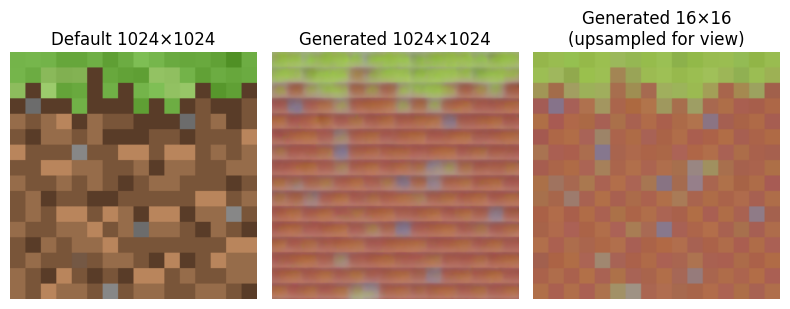

In [17]:
from typing import List, Dict

# Style reference textures (define pack-level style)
STYLE_REFERENCE_TEXTURES: List[str] = [
    "grass_block_side",
    "stone",
    "oak_log_top",
    "sand",
    "dirt",
    "cobblestone",
    "oak_planks",
    "glass",
    "iron_ore",
    "diamond_ore",
]

def compute_style_delta_embedding(
    embeddings_cache,
    pack_id: str,
    texture_name: str,
    style_refs: List[str],
) -> torch.Tensor:
    """
    Average CLIP delta vectors over a fixed set of style reference textures,
    using the same 'delta' entries as TripletMinecraftDataset.
    """
    # Restrict to style_refs that exist in the cache and aren't the target itself
    names = [
        t for t in style_refs
        if t != texture_name and t in embeddings_cache[pack_id]
    ]
    if not names:
        # Fallback: just use the target texture if nothing else is available
        names = [texture_name]

    vectors = [embeddings_cache[pack_id][n]["delta"] for n in names]
    style_embed = torch.stack(vectors).mean(dim=0)
    norm = style_embed.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    return style_embed / norm

def find_sample(dataset, pack_id: str, texture_name: str):
    """
    TripletMinecraftDataset.samples: (pack_id, texture_name, idx)
    Use that to get the normalized default image from test_dataset.
    """
    for i, (p_id, t_name, _) in enumerate(dataset.samples):
        if p_id == pack_id and t_name == texture_name:
            return dataset[i]
    return None

PACK_ID = "plastic-texture-pack"
TARGET_NAME = "grass_block_side"

# 1) Grab a matching sample from the test split
sample = find_sample(test_dataset, PACK_ID, TARGET_NAME)
if sample is None:
    raise RuntimeError(f"No sample for {PACK_ID}/{TARGET_NAME} found in test_dataset.")

# default_image is a normalized tensor in [-1, 1]; convert back to a 1024×1024 RGB PIL image
default_tensor = sample["default_image"].detach().cpu()
default_img_np = (default_tensor * 0.5 + 0.5).clamp(0, 1)  # [-1,1] -> [0,1]
default_img_np = (default_img_np * 255).permute(1, 2, 0).byte().numpy()
default_img_1024 = Image.fromarray(default_img_np)

# 2) Build style embedding from CLIP delta cache using STYLE_REFERENCE_TEXTURES
style_embed = compute_style_delta_embedding(
    embeddings_cache,
    PACK_ID,
    TARGET_NAME,
    STYLE_REFERENCE_TEXTURES,
)
style_embed = style_embed.to(
    device=pipe.unet.device,
    dtype=next(pipe.unet.parameters()).dtype,
)

with torch.no_grad():
    raw_clip_embed = style_embed.unsqueeze(0)
    neg_clip_embed = torch.zeros_like(raw_clip_embed)

    ip_tokens_pos = ip_model.image_proj_model(raw_clip_embed.unsqueeze(1))
    ip_tokens_neg = ip_model.image_proj_model(neg_clip_embed.unsqueeze(1))
    ip_adapter_embeds = torch.cat([ip_tokens_neg, ip_tokens_pos], dim=0)

# 3) Single img2img generation
os.makedirs("results_qualitative", exist_ok=True)
with torch.no_grad():
    out = pipe(
        prompt=f"minecraft texture of {TARGET_NAME.replace('_', ' ')}",
        image=default_img_1024,
        cross_attention_kwargs={"ip_adapter_embeds": ip_adapter_embeds},
        strength=0.65,  # 0.65 as requested
        guidance_scale=7.5,
        num_inference_steps=30,
    )

gen_img_1024 = out.images[0]

# Save 1024×1024 generated image
save_path_1024 = os.path.join(
    "results_qualitative", f"{PACK_ID}_{TARGET_NAME}_generated_1024.png"
)
gen_img_1024.save(save_path_1024)

# Create and save 16×16 version (downscaled with nearest neighbor)
gen_img_16 = gen_img_1024.resize((16, 16), resample=Image.NEAREST)
save_path_16 = os.path.join(
    "results_qualitative", f"{PACK_ID}_{TARGET_NAME}_generated_16.png"
)
gen_img_16.save(save_path_16)

print(f"[OK] Saved Plastic {TARGET_NAME} samples to:\n  {save_path_1024}\n  {save_path_16}")

# 4) Optional: download both images in Colab
# try:
#    from google.colab import files
#    files.download(save_path_1024)
#    files.download(save_path_16)
#except ImportError:
#    print("google.colab not available; skipping automatic download.")

# 5) Show with matplotlib (default vs generated; plus 16×16 as a third panel)
plt.figure(figsize=(8, 3))

plt.subplot(1, 3, 1)
plt.imshow(default_img_1024)
plt.title("Default 1024×1024")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gen_img_1024)
plt.title("Generated 1024×1024")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gen_img_16.resize((128, 128), resample=Image.NEAREST))
plt.title("Generated 16×16\n(upsampled for view)")
plt.axis("off")

plt.tight_layout()
plt.show()

plastic-texture-pack: 20 style exemplars


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

steampunk-texture-pack: 20 eval textures


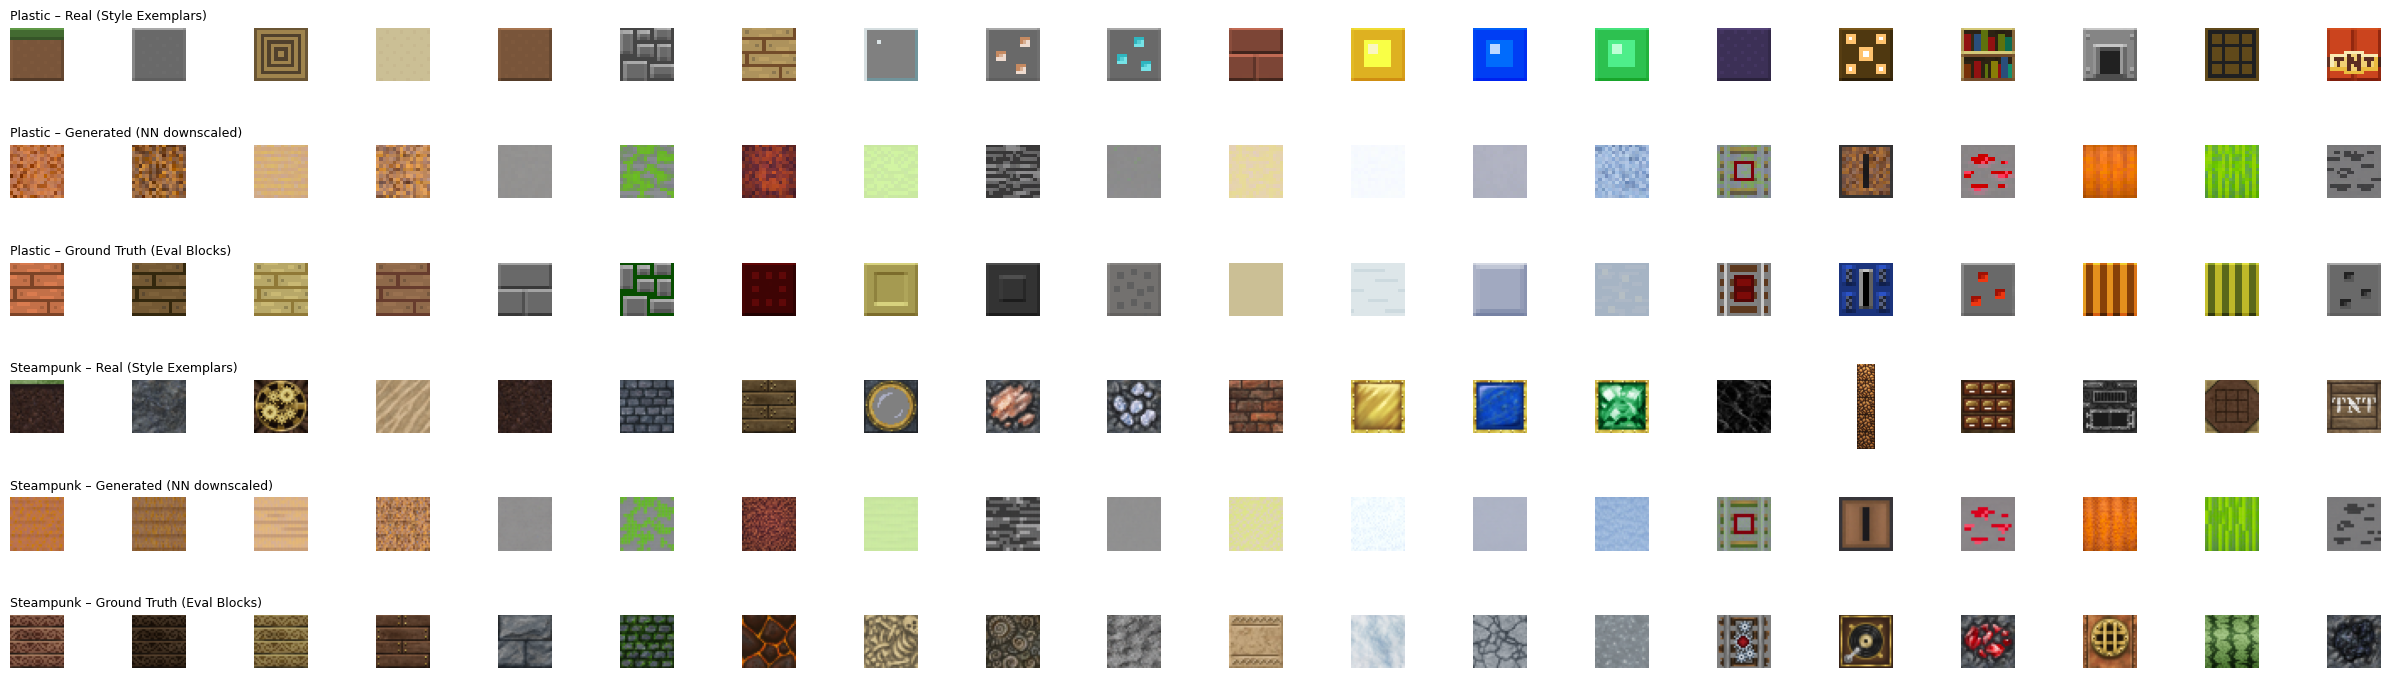

[OK] Saved qualitative grid to results_quantitative/plastic_steampunk_qualitative_grid.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


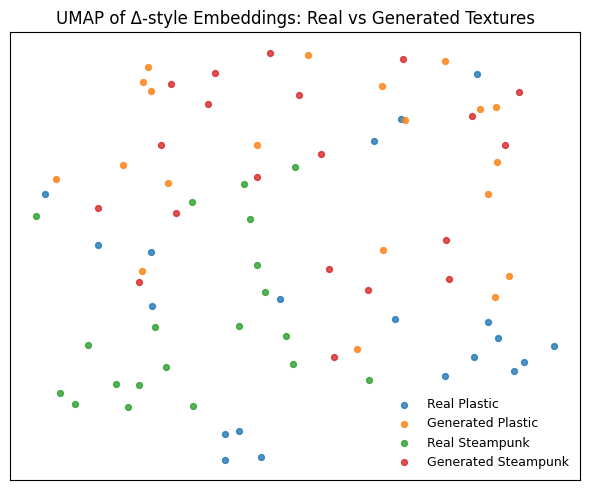

[OK] Saved UMAP plot to results_quantitative/testpack_umap.png


In [18]:
import numpy as np
from umap.umap_ import UMAP

# CLIP model reused from earlier
_clip_model = model.to(device)
_clip_preprocess = preprocess
_clip_device = device
_clip_model.eval()

@torch.inference_mode()
def clip_embed_image(img: Image.Image) -> torch.Tensor:
    img_tensor = _clip_preprocess(img).unsqueeze(0).to(_clip_device)
    with torch.autocast(
        device_type=("cuda" if "cuda" in str(_clip_device) else "cpu"),
        enabled=("cuda" in str(_clip_device)),
    ):
        feat = _clip_model.encode_image(img_tensor)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.squeeze(0).cpu()

def delta_style_embedding(img: Image.Image, default_img: Image.Image) -> torch.Tensor:
    e_img = clip_embed_image(img)
    e_def = clip_embed_image(default_img)
    return e_img - e_def

TEST_PACKS = ["plastic-texture-pack", "steampunk-texture-pack"]

# 20 exemplar blocks (top rows; also used in style embedding code elsewhere)
STYLE_REFERENCE_TEXTURES: List[str] = [
    "grass_block_side",
    "stone",
    "oak_log_top",
    "sand",
    "dirt",
    "cobblestone",
    "oak_planks",
    "glass",
    "iron_ore",
    "diamond_ore",
    "bricks",
    "gold_block",
    "lapis_block",
    "emerald_block",
    "obsidian",
    "glowstone",
    "bookshelf",
    "furnace_front",
    "crafting_table_top",
    "tnt_side",
]

# 20 different eval blocks (middle + bottom rows and UMAP)
EVAL_TEXTURES: List[str] = [
    "acacia_planks",
    "spruce_planks",
    "birch_planks",
    "jungle_planks",
    "stone_bricks",
    "mossy_cobblestone",
    "netherrack",
    "end_stone",
    "bedrock",
    "gravel",
    "sandstone_top",
    "snow",
    "clay",
    "ice",
    "detector_rail",
    "jukebox_top",
    "redstone_ore",
    "pumpkin_side",
    "melon_side",
    "coal_ore",
]

if len(STYLE_REFERENCE_TEXTURES) != 20 or len(EVAL_TEXTURES) != 20:
    raise ValueError("STYLE_REFERENCE_TEXTURES and EVAL_TEXTURES must each have length 20.")

overlap = set(STYLE_REFERENCE_TEXTURES) & set(EVAL_TEXTURES)
if overlap:
    raise ValueError(f"Exemplar and eval sets must be disjoint; overlap: {overlap}")

# Index default textures
default_name_to_idx: Dict[str, int] = {
    item["texture_name"]: idx for idx, item in enumerate(default_dataset)
}

# Index textures inside each test pack
pack_name_to_idx: Dict[str, Dict[str, int]] = {}
for pack_id in TEST_PACKS:
    name_to_idx: Dict[str, int] = {}
    for idx, item in enumerate(pack_datasets[pack_id]):
        name_to_idx[item["texture_name"]] = idx
    pack_name_to_idx[pack_id] = name_to_idx

# Sanity: all exemplars and evals must exist in default + both packs
for name in STYLE_REFERENCE_TEXTURES + EVAL_TEXTURES:
    if name not in default_name_to_idx:
        raise KeyError(f"default_dataset missing texture '{name}'")
    for pack_id in TEST_PACKS:
        if name not in pack_name_to_idx[pack_id]:
            raise KeyError(f"{pack_id} missing texture '{name}'")

@torch.inference_mode()
def generate_downscaled_texture(pack_id: str, texture_name: str, target_size):
    d_idx = default_name_to_idx[texture_name]
    default_item = default_dataset[d_idx]
    default_img_16 = default_item["image_rgb"].convert("RGB")
    default_img_1024 = default_img_16.resize((1024, 1024), resample=Image.NEAREST)

    style_embed = compute_style_delta_embedding(
        embeddings_cache,
        pack_id,
        texture_name,
        STYLE_REFERENCE_TEXTURES,
    )
    style_embed = style_embed.to(
        device=pipe.unet.device,
        dtype=next(pipe.unet.parameters()).dtype,
    )

    raw_clip_embed = style_embed.unsqueeze(0)
    neg_clip_embed = torch.zeros_like(raw_clip_embed)

    ip_tokens_pos = ip_model.image_proj_model(raw_clip_embed.unsqueeze(1))
    ip_tokens_neg = ip_model.image_proj_model(neg_clip_embed.unsqueeze(1))
    ip_adapter_embeds = torch.cat([ip_tokens_neg, ip_tokens_pos], dim=0)

    out = pipe(
        prompt=f"minecraft texture of {texture_name.replace('_', ' ')}",
        image=default_img_1024,
        cross_attention_kwargs={"ip_adapter_embeds": ip_adapter_embeds},
        strength=0.65,
        guidance_scale=7.5,
        num_inference_steps=30,
    )

    gen_img_1024 = out.images[0]
    gen_small = gen_img_1024.resize(target_size, resample=Image.NEAREST)
    return gen_small, default_img_16

rows_images: List[List[Image.Image]] = [[] for _ in range(6)]
row_titles = [
    "Plastic – Real (Style Exemplars)",
    "Plastic – Generated (NN downscaled)",
    "Plastic – Ground Truth (Eval Blocks)",
    "Steampunk – Real (Style Exemplars)",
    "Steampunk – Generated (NN downscaled)",
    "Steampunk – Ground Truth (Eval Blocks)",
]

pack_to_row_offset = {
    "plastic-texture-pack": 0,  # rows 0,1,2
    "steampunk-texture-pack": 3,  # rows 3,4,5
}

features: List[torch.Tensor] = []
labels: List[int] = []

def label_id(pack_id: str, generated: bool) -> int:
    if pack_id == "plastic-texture-pack":
        return 1 if generated else 0
    elif pack_id == "steampunk-texture-pack":
        return 3 if generated else 2
    else:
        raise ValueError(pack_id)

max_style_cols = 0
max_eval_cols = 0

for pack_id in TEST_PACKS:
    row_offset = pack_to_row_offset[pack_id]

    # Top row: 20 real style exemplars (per pack)
    exemplars_this_pack = []
    for tex_name in STYLE_REFERENCE_TEXTURES:
        idx = pack_name_to_idx[pack_id][tex_name]
        item = pack_datasets[pack_id][idx]
        img = item["image_rgb"].convert("RGB")
        rows_images[row_offset + 0].append(img)
        exemplars_this_pack.append(img)
    max_style_cols = max(max_style_cols, len(exemplars_this_pack))
    print(f"{pack_id}: {len(exemplars_this_pack)} style exemplars")

    # Middle/bottom rows + Δ-style features for UMAP
    eval_count = 0
    for tex_name in EVAL_TEXTURES:
        idx = pack_name_to_idx[pack_id][tex_name]
        real_item = pack_datasets[pack_id][idx]
        real_img = real_item["image_rgb"].convert("RGB")
        target_size = real_img.size

        gen_img_small, default_img_16 = generate_downscaled_texture(
            pack_id,
            tex_name,
            target_size,
        )

        # middle row: generated evals
        rows_images[row_offset + 1].append(gen_img_small)
        # bottom row: pack ground-truth evals
        rows_images[row_offset + 2].append(real_img)

        real_feat = delta_style_embedding(real_img, default_img_16)
        features.append(real_feat)
        labels.append(label_id(pack_id, generated=False))

        gen_feat = delta_style_embedding(gen_img_small, default_img_16)
        features.append(gen_feat)
        labels.append(label_id(pack_id, generated=True))

        eval_count += 1

    max_eval_cols = max(max_eval_cols, eval_count)
    print(f"{pack_id}: {eval_count} eval textures")

ncols = max(max_style_cols, max_eval_cols)
nrows = 6

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 1.2, nrows * 1.2),
)

if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes.reshape(nrows, 1)

for row_idx in range(nrows):
    for col_idx in range(ncols):
        ax = axes[row_idx, col_idx]
        ax.axis("off")
        if col_idx < len(rows_images[row_idx]):
            ax.imshow(np.asarray(rows_images[row_idx][col_idx]))
    axes[row_idx, 0].set_title(row_titles[row_idx], fontsize=9, loc="left")

plt.tight_layout()

results_dir = "results_quantitative"
os.makedirs(results_dir, exist_ok=True)
qual_path = os.path.join(results_dir, "plastic_steampunk_qualitative_grid.png")
plt.savefig(qual_path, dpi=200)
plt.show()
print(f"[OK] Saved qualitative grid to {qual_path}")

if len(features) == 0:
    raise RuntimeError("No features collected for UMAP.")

features_np = torch.stack(features, dim=0).numpy()

umap = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
coords = umap.fit_transform(features_np)

labels_np = np.array(labels)

label_to_name = {
    0: "Real Plastic",
    1: "Generated Plastic",
    2: "Real Steampunk",
    3: "Generated Steampunk",
}
label_to_color = {
    0: "C0",
    1: "C1",
    2: "C2",
    3: "C3",
}

plt.figure(figsize=(6, 5))
for lbl in sorted(label_to_name.keys()):
    mask = labels_np == lbl
    if not np.any(mask):
        continue
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        s=18,
        alpha=0.8,
        label=label_to_name[lbl],
        c=label_to_color[lbl],
    )

plt.legend(frameon=False, fontsize=9)
plt.xticks([])
plt.yticks([])
plt.title("UMAP of Δ-style Embeddings: Real vs Generated Textures")
plt.tight_layout()

umap_path = os.path.join(results_dir, "testpack_umap.png")
plt.savefig(umap_path, dpi=200)
plt.show()
print(f"[OK] Saved UMAP plot to {umap_path}")
